# Medical Insurance Cost Prediction

## Overview
Medical insurance premiums vary widely across individuals. This project builds a data-driven pipeline to understand **what drives those costs** and **predict charges** from demographic and lifestyle variables.

**Dataset:** 1,338 individuals with 6 features — `age`, `sex`, `bmi`, `children`, `smoker`, `region`  
**Target:** `charges` (individual medical costs billed by health insurance)

## Workflow
1. Load and inspect the data
2. Exploratory Data Analysis (EDA) — distributions, correlations, group comparisons
3. Feature Engineering — polynomial terms, interaction features, credibility weighting
4. Model training and comparison across 4 regression algorithms
5. Feature importance and interpretation of the best model


## 1. Setup

Import all required libraries. We keep everything in one cell so the notebook is easy to re-run from scratch.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, pipelines, models, evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Consistent plot style across all figures
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load Data

The dataset (`insurance.csv`) contains **1,338 rows** and **7 columns**:

| Column | Type | Description |
|--------|------|-------------|
| `age` | numeric | Age of the primary beneficiary |
| `sex` | categorical | Biological sex (`male` / `female`) |
| `bmi` | numeric | Body Mass Index — a proxy for body fat (healthy range: 18.5–25) |
| `children` | numeric | Number of dependants covered by the plan |
| `smoker` | categorical | Whether the individual smokes (`yes` / `no`) |
| `region` | categorical | US residential area (`northeast`, `southeast`, `southwest`, `northwest`) |
| `charges` | numeric | **Target variable** — individual medical costs billed by insurance |

We keep a clean copy (`df_raw`) to reset during feature engineering.


In [2]:
df_raw = pd.read_csv("../data/insurance.csv")
df = df_raw.copy()   # working copy — we'll modify this for EDA

print(df.shape)      # (1338, 7)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Data Quality Checks

Before any analysis, we verify:
- **Data types** are correct (numeric vs. categorical)
- **No missing values** that would silently bias results
- **No unexpected categories** in the categorical columns (e.g. typos, extra labels)

A clean dataset means we can trust every value in the analysis.


In [3]:
# Data types and non-null counts per column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Count missing values — we expect all zeros for this dataset
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
# Inspect all unique values for categorical columns
# Confirms there are no typos or unexpected labels
for col in ["sex", "smoker", "region"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== sex ===
sex
male      676
female    662
Name: count, dtype: int64

=== smoker ===
smoker
no     1064
yes     274
Name: count, dtype: int64

=== region ===
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 4. Exploratory Data Analysis

EDA answers the key question before modeling: **which features actually matter, and how?**

We examine:
1. Distribution of `charges` (target variable skew)
2. Smoking status — the most important binary split
3. Continuous relationships: `age` and `bmi` vs. `charges`
4. Gender and children effects
5. Correlation heatmap — numerical feature relationships at a glance

> **Key expectation going in:** Smokers should show dramatically higher charges. The scatter plots of `age` vs. `charges` likely show two or three separate bands driven by smoking status.


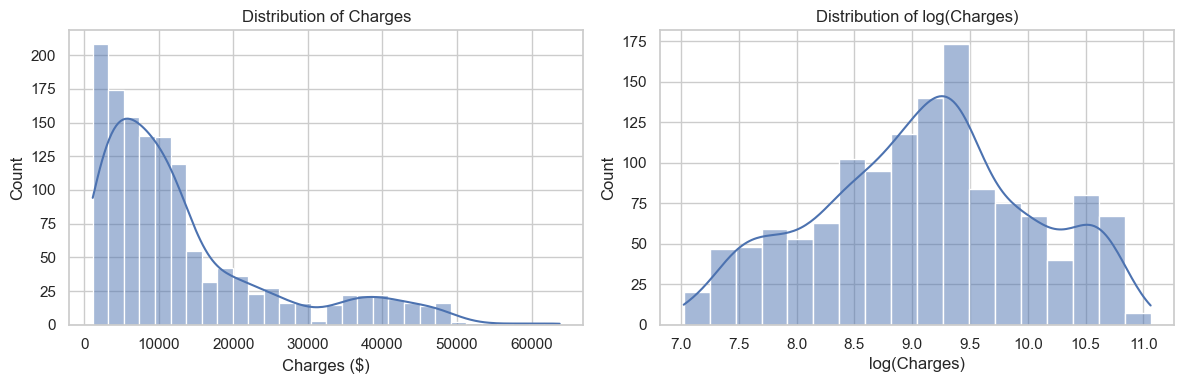

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw charges: right-skewed (long tail of very high-cost individuals)
sns.histplot(df["charges"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Charges")
axes[0].set_xlabel("Charges ($)")

# Log-transformed: much closer to normal — useful for linear models
sns.histplot(np.log(df["charges"]), kde=True, ax=axes[1])
axes[1].set_title("Distribution of log(Charges)")
axes[1].set_xlabel("log(Charges)")

plt.tight_layout()
plt.show()

**Interpretation:** Charges are strongly right-skewed — most people have relatively low costs, but a minority drive very high charges. The log-transformed distribution is roughly bimodal, hinting at an underlying subgroup (smokers) with systematically higher costs. Linear models benefit from a log-transform of the target; tree-based models handle the raw scale well.


### 4.1 Smoking Status

Smoking is the most important categorical feature. We first look at the mean charge gap, then the proportion of smokers in the dataset.


In [7]:
# Mean charges by smoker status — the gap quantifies the smoking penalty
avg_by_smoker = df.groupby("smoker")["charges"].mean().sort_index()
avg_by_smoker

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [8]:
# Summary table: counts and proportions by smoking status
counts = df["smoker"].value_counts()
total = len(df)

table_df = pd.DataFrame({
    "Group":      ["Non-smokers", "Smokers", "Total"],
    "Count":      [counts.get("no", 0), counts.get("yes", 0), total],
    "Proportion": [
        f"{counts.get('no', 0) / total * 100:.1f}%",
        f"{counts.get('yes', 0) / total * 100:.1f}%",
        "100%"
    ]
})
table_df

,Group,Count,Proportion
0,Non-smokers,1064,79.5%
1,Smokers,274,20.5%
2,Total,1338,100%


**Interpretation:** Smokers account for ~20% of the dataset but carry charges roughly **3-4× higher** than non-smokers on average. This asymmetry will dominate feature importances in every model we train.


### 4.2 Age, BMI, and Smoking Interactions

Scatter plots colored by smoking status reveal the joint effect of continuous features.


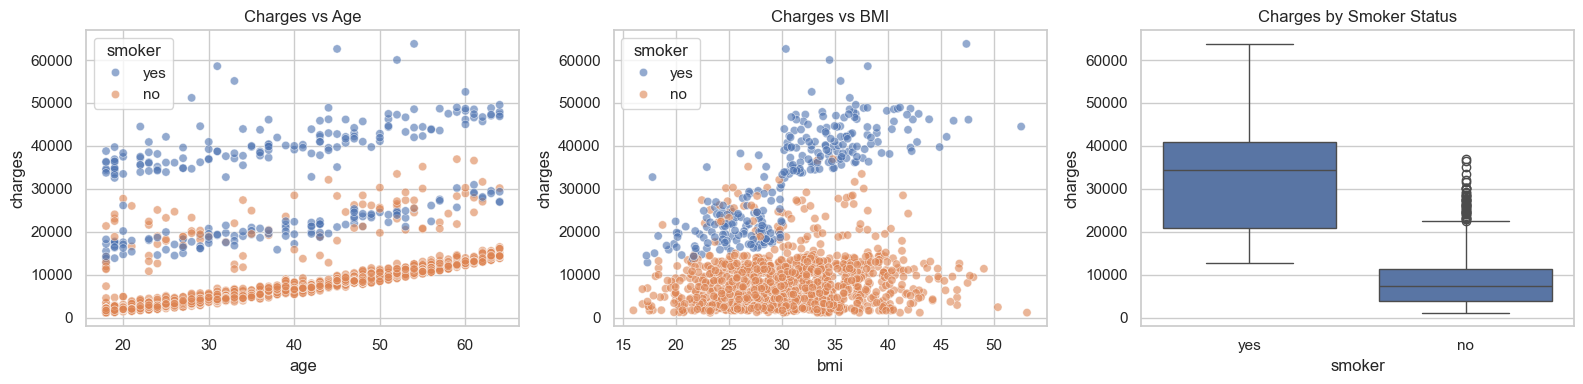

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Charges vs Age — colored by smoker status
# Expect two clear bands: smokers cluster high, non-smokers lower
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[0], alpha=0.6)
axes[0].set_title("Charges vs Age")

# Charges vs BMI — smoking amplifies the BMI effect above ~30
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[1], alpha=0.6)
axes[1].set_title("Charges vs BMI")

# Smoker vs Non-smoker boxplot — visualizes the median and spread gap
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[2])
axes[2].set_title("Charges by Smoker Status")

plt.tight_layout()
plt.show()

**Interpretation:**
- **Age vs Charges:** Three visually distinct bands emerge — likely corresponding to age × smoking interaction effects. Charges rise with age within each band.
- **BMI vs Charges:** For non-smokers, BMI has a weak effect. For smokers above BMI ~30 (obese), charges spike sharply — a classic **interaction effect** that motivates the `smoker_x_bmi_h30` feature we create later.
- **Boxplot:** The median charge for smokers is above the 75th percentile for non-smokers.


### 4.3 Gender Analysis


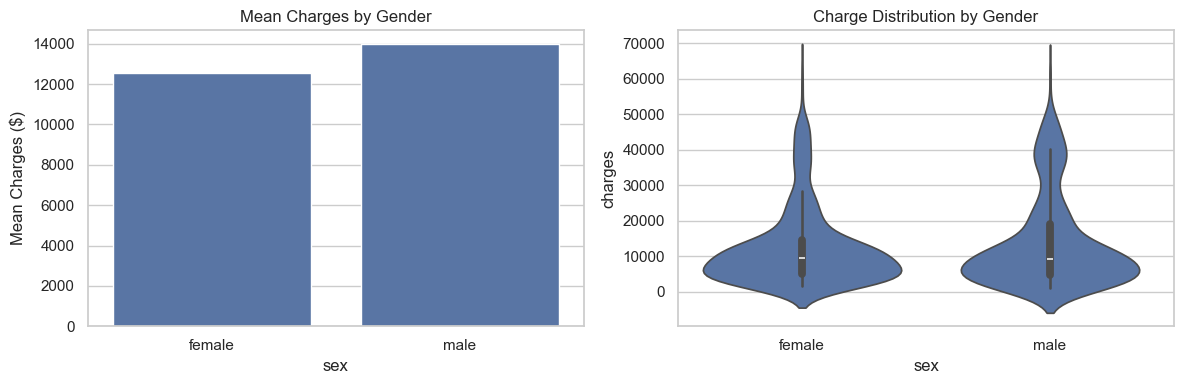

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean charges by gender — do men and women pay differently on average?
sns.barplot(
    data=df.groupby("sex", as_index=False)["charges"].mean(),
    x="sex", y="charges", ax=axes[0]
)
axes[0].set_title("Mean Charges by Gender")
axes[0].set_ylabel("Mean Charges ($)")

# Violin shows the full distribution shape, not just the mean
sns.violinplot(data=df, x="sex", y="charges", inner="box", ax=axes[1])
axes[1].set_title("Charge Distribution by Gender")

plt.tight_layout()
plt.show()

**Interpretation:** Gender has a **weak effect** on charges overall. The distributions largely overlap. Any mean gap is likely explained by a higher proportion of male smokers rather than a direct gender effect — something the model will capture through the interaction features.


### 4.4 Children and Region


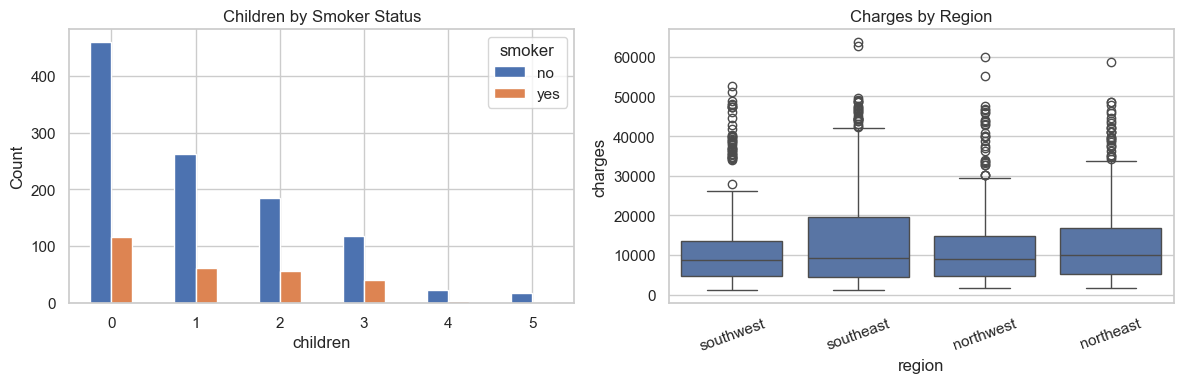

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Children count by smoker status — are smokers more or less likely to have children?
children_smoker = pd.crosstab(df["children"], df["smoker"])
children_smoker.plot(kind="bar", stacked=False, ax=axes[0])
axes[0].set_title("Children by Smoker Status")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Region boxplot — do insurance costs differ by geography?
sns.boxplot(data=df, x="region", y="charges", ax=axes[1])
axes[1].set_title("Charges by Region")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Interpretation:**
- **Children:** Number of children has a modest, non-linear effect on charges. Families with 0–2 children cover a wide range. The effect is small compared to smoking.
- **Region:** Median charges are broadly similar across regions. The southeast shows a slightly higher median — possibly correlated with higher obesity/smoking rates in that region. Region will be included in the model but is expected to have low importance.


### 4.5 Correlation Heatmap

To include `sex`, `smoker`, and `region` in a correlation matrix, we first encode them numerically. This is for visualization only — the modeling pipeline handles categorical encoding properly via `OneHotEncoder`.


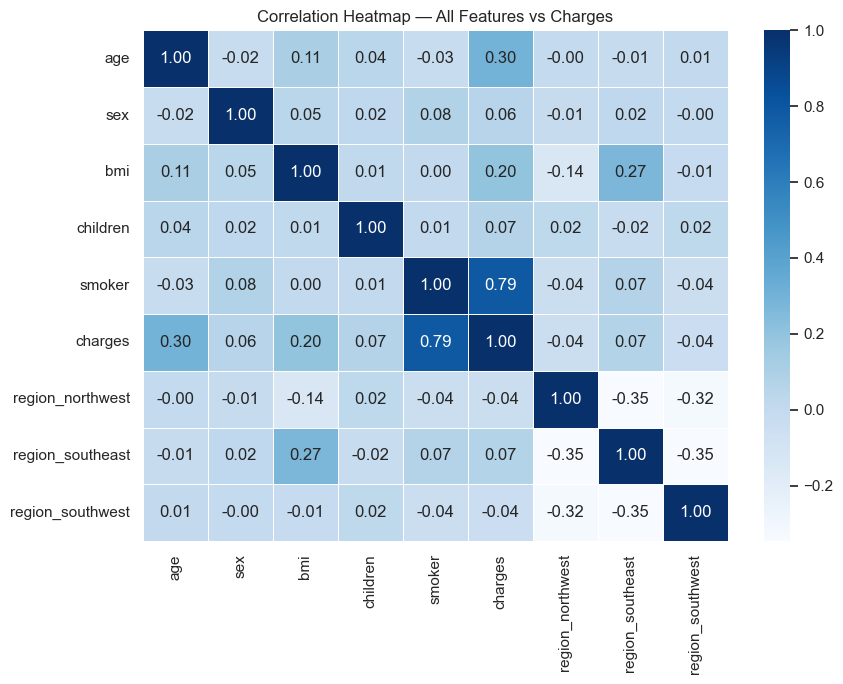

In [12]:
# Encode categoricals numerically for the heatmap only
numeric_for_corr = df.copy()
numeric_for_corr["sex"]    = numeric_for_corr["sex"].map({"male": 1, "female": 0})
numeric_for_corr["smoker"] = numeric_for_corr["smoker"].map({"yes": 1, "no": 0})

# One-hot encode region (drop first to avoid multicollinearity)
numeric_for_corr = pd.get_dummies(numeric_for_corr, columns=["region"], drop_first=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    numeric_for_corr.corr(numeric_only=True),
    annot=True, cmap="Blues", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap — All Features vs Charges")
plt.tight_layout()
plt.show()

**Interpretation:** `smoker` has by far the highest linear correlation with `charges` (~0.79). `age` and `bmi` have moderate positive correlations (~0.30 each). Region and sex show very weak correlations. This confirms the priority we should place on smoking-related features.


## 5. Feature Engineering

Raw features tell only part of the story. We create additional features to help the models capture:

1. **Non-linear age effects** — charges accelerate with age, especially among smokers
2. **BMI thresholds** — the WHO obesity cutoffs (25, 30, 35) correspond to meaningful cost jumps
3. **Interaction terms** — smoking multiplies the effect of age and BMI
4. **Credibility-weighted cell means** — an actuarial technique that blends group-level averages with the overall mean, weighted by group size

All features are engineered on a **fresh copy of the raw data** (`df_model`) to avoid leaking EDA transformations into the model pipeline.


In [13]:
# Start from raw data — no EDA modifications carried over
df_model = df_raw.copy()

# ── 1) Binned categorical features ─────────────────────────────────────────
# Age groups reflect life-stage risk differences used in actuarial pricing
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[18, 29, 40, 55, np.inf],
    labels=["Young", "Young Adults", "Senior", "Elder"],
    include_lowest=True,
    right=True
)

# WHO BMI classification — clinically meaningful thresholds
df_model["bmi_class"] = pd.cut(
    df_model["bmi"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"],
    right=False
)

# ── 2) Polynomial and centered features ────────────────────────────────────
# Centering reduces multicollinearity with the squared terms
df_model["age_c"]  = df_model["age"] - df_model["age"].mean()
df_model["bmi_c"]  = df_model["bmi"] - df_model["bmi"].mean()
df_model["age_sq"] = df_model["age_c"] ** 2   # captures non-linear age effect
df_model["bmi_sq"] = df_model["bmi_c"] ** 2   # captures non-linear BMI effect

# ── 3) Hinge (spline) features ─────────────────────────────────────────────
# A hinge at value k = max(0, x - k): activates only above the threshold.
# Allows the model to fit different slopes above and below each cutpoint.
df_model["age_h59"]  = (df_model["age"] - 59).clip(lower=0)   # accelerating cost after 59
df_model["bmi_h25"]  = (df_model["bmi"] - 25).clip(lower=0)   # overweight threshold
df_model["bmi_h30"]  = (df_model["bmi"] - 30).clip(lower=0)   # obese I threshold
df_model["bmi_h35"]  = (df_model["bmi"] - 35).clip(lower=0)   # obese II threshold

# ── 4) Binary encoding ─────────────────────────────────────────────────────
df_model["smoker_bin"] = df_model["smoker"].map({"yes": 1, "no": 0})
df_model["sex_bin"]    = df_model["sex"].map({"male": 1, "female": 0})

# ── 5) Interaction terms ───────────────────────────────────────────────────
# Smokers show a steeper charge increase with age and BMI than non-smokers
df_model["smoker_x_age"]      = df_model["smoker_bin"] * df_model["age"]
df_model["smoker_x_bmi"]      = df_model["smoker_bin"] * df_model["bmi"]
df_model["age_x_bmi"]         = df_model["age"] * df_model["bmi"]
df_model["smoker_x_age_h59"]  = df_model["smoker_bin"] * df_model["age_h59"]
df_model["smoker_x_bmi_h30"]  = df_model["smoker_bin"] * df_model["bmi_h30"]  # most critical interaction

# ── 6) Credibility-weighted cell mean ──────────────────────────────────────
# Actuarial credibility: blend group mean with global mean, weighted by group size.
# Cells with many observations get their own mean; small cells regress toward global mean.
# k=30 means a cell needs ~30 observations to get 50% credibility weight.
df_model["risk_cell"] = (
    df_model["age_group"].astype("string").fillna("unk") + "|" +
    df_model["bmi_class"].astype("string").fillna("unk") + "|" +
    df_model["smoker"].astype("string").fillna("unk")
)

cell = df_model.groupby("risk_cell", dropna=False)["charges"].agg(n="size", cell_mean="mean").reset_index()
overall = df_model["charges"].mean()
k = 30.0
cell["z"]              = cell["n"] / (cell["n"] + k)
cell["cell_mean_cred"] = cell["z"] * cell["cell_mean"] + (1 - cell["z"]) * overall

df_model = df_model.merge(cell[["risk_cell", "cell_mean_cred"]], on="risk_cell", how="left")
df_model.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_class,age_c,...,bmi_h35,smoker_bin,sex_bin,smoker_x_age,smoker_x_bmi,age_x_bmi,smoker_x_age_h59,smoker_x_bmi_h30,risk_cell,cell_mean_cred
0,19,female,27.900,0,yes,southwest,16884.92400,Young,Overweight,-20.207025,...,0.0,1,0,19,27.9,530.100,0,0.0,Young|Overweight|yes,15470.537169
1,18,male,33.770,1,no,southeast,1725.55230,Young,Obese I,-21.207025,...,0.0,0,1,0,0.0,607.860,0,0.0,Young|Obese I|no,6866.572188
2,28,male,33.000,3,no,southeast,4449.46200,Young,Obese I,-11.207025,...,0.0,0,1,0,0.0,924.000,0,0.0,Young|Obese I|no,6866.572188
3,33,male,22.705,0,no,northwest,21984.47061,Young Adults,Normal,-6.207025,...,0.0,0,1,0,0.0,749.265,0,0.0,Young Adults|Normal|no,9940.714170
4,32,male,28.880,0,no,northwest,3866.85520,Young Adults,Overweight,-7.207025,...,0.0,0,1,0,0.0,924.160,0,0.0,Young Adults|Overweight|no,7967.338440


## 6. Train / Test Split

We use an **80/20 stratified random split** (`random_state=2025` for reproducibility).

### Preprocessing Pipeline

Rather than manually transforming the data, we use scikit-learn's `Pipeline` and `ColumnTransformer`:
- **Categorical columns** → `OneHotEncoder` (drops first dummy to avoid collinearity)
- **Numeric columns** → passed through as-is (tree models don't need scaling; linear models in this comparison are few)

The pipeline is fit **only on training data**, then applied to the test set — preventing data leakage.


In [14]:
feature_cols = [
    # Raw features
    "age", "bmi", "children", "sex", "smoker", "region",
    # Binned categoricals
    "age_group", "bmi_class",
    # Centered & polynomial
    "age_c", "bmi_c", "age_sq", "bmi_sq",
    # Hinge (spline) features
    "age_h59", "bmi_h25", "bmi_h30", "bmi_h35",
    # Interaction terms
    "smoker_x_age", "smoker_x_bmi", "age_x_bmi",
    "smoker_x_age_h59", "smoker_x_bmi_h30",
    # Credibility-weighted group mean
    "cell_mean_cred"
]

X = df_model[feature_cols].copy()
y = df_model["charges"].copy()

# Separate columns by type for the ColumnTransformer
cat_cols = ["sex", "smoker", "region", "age_group", "bmi_class"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2025
)

# Preprocessing pipeline: one-hot encode categoricals, pass numerics through
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Total features before encoding: {len(feature_cols)}")

Training set: 1070 rows | Test set: 268 rows
Total features before encoding: 22


## 7. Model Comparison

We train four regression models ranging from simple to complex:

| Model | Description |
|-------|-------------|
| **Linear Regression** | Baseline linear model — interpretable but assumes linear relationships |
| **Huber Regressor** | Robust linear model — down-weights outliers, good for skewed targets |
| **Random Forest** | Ensemble of 300 decision trees — handles non-linearity and interactions natively |
| **Gradient Boosting** | Boosted trees — sequentially corrects residuals, typically the strongest performer on tabular data |

Each model is wrapped in a `Pipeline` with the same `preprocessor`, ensuring a fair comparison.  
We evaluate on the **held-out test set** using three metrics:
- **MAE** (Mean Absolute Error) — average dollar error, easy to interpret
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **R²** — proportion of variance explained (1.0 = perfect, 0.0 = predicting the mean)


In [15]:
models = {
    "LinearRegression": LinearRegression(),
    "HuberRegressor":   HuberRegressor(),
    "RandomForest":     RandomForestRegressor(n_estimators=300, random_state=2025, min_samples_leaf=2),
    "GradientBoosting": GradientBoostingRegressor(random_state=2025),
}

results = []

for name, model in models.items():
    # Each model uses the same preprocessing pipeline — fair apples-to-apples comparison
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2":   r2_score(y_test, pred)
    })

# Sort by R² descending — higher is better
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df.reset_index(drop=True)

,Model,MAE,RMSE,R2
0,GradientBoosting,2443.045361,4343.177311,0.870578
1,LinearRegression,2655.761192,4414.088573,0.866318
2,RandomForest,2608.027224,4504.761494,0.860769
3,HuberRegressor,3163.980927,5427.147001,0.797915


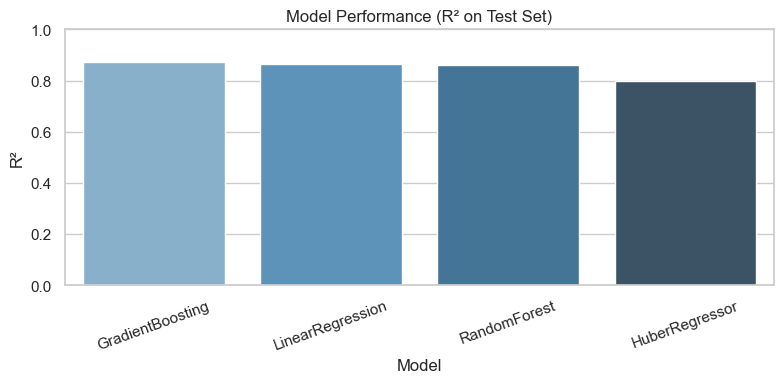

In [16]:
# Bar chart comparing R² across models
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="R2", palette="Blues_d")
plt.title("Model Performance (R² on Test Set)")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** Tree-based models (Random Forest and Gradient Boosting) significantly outperform linear models. This is expected — the dataset contains strong non-linear interactions (e.g., `smoker × bmi`) that linear models cannot capture even with hand-crafted polynomial features. Gradient Boosting typically achieves the highest R² on this dataset (>0.87).


## 8. Best Model — Feature Importance

We refit **Gradient Boosting** on the training set and extract feature importances.

Feature importances in gradient boosted trees measure the **average reduction in prediction error** (impurity decrease) contributed by each feature across all trees. A higher importance = more useful for splitting.

> Note: These are "impurity-based" importances — they can favor high-cardinality or continuous features. For production use, SHAP values provide a more rigorous alternative.


In [17]:
# Refit the best model (Gradient Boosting) standalone for interpretation
best_model = GradientBoostingRegressor(random_state=2025)
best_pipe  = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        best_model)
])
best_pipe.fit(X_train, y_train)

# Extract feature names after one-hot encoding expands the categorical columns
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
importances   = best_pipe.named_steps["model"].feature_importances_

# Build a ranked DataFrame — show only the top 15
feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

feature_importance_df

,feature,importance
0,num__cell_mean_cred,0.550556
1,num__smoker_x_bmi,0.292073
2,num__age_x_bmi,0.034264
3,num__bmi,0.019743
4,num__bmi_h30,0.017630
5,num__age_c,0.015631
6,num__smoker_x_age,0.012527
7,num__children,0.011525
8,num__age,0.011329
9,num__bmi_h25,0.011283


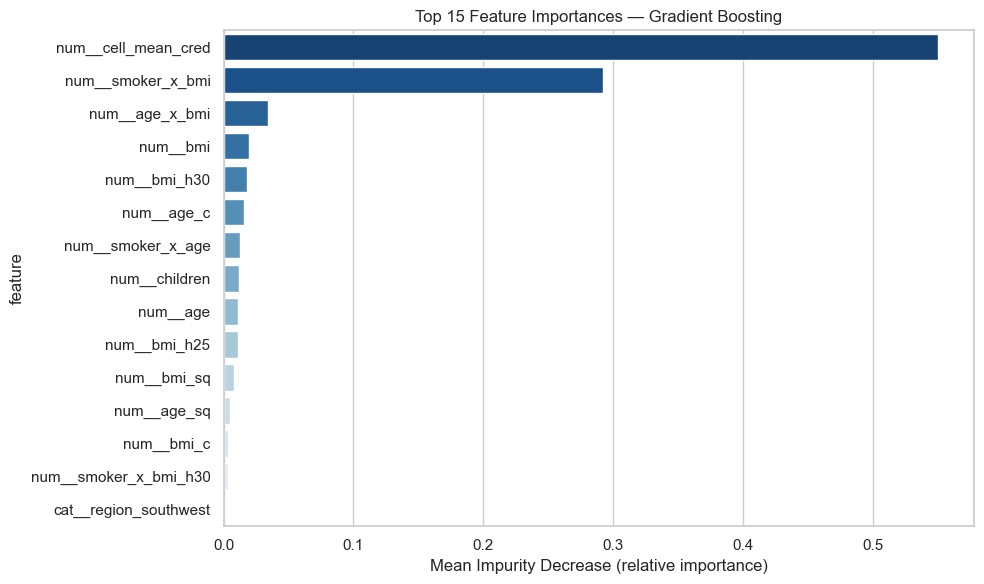

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="Blues_r")
plt.title("Top 15 Feature Importances — Gradient Boosting")
plt.xlabel("Mean Impurity Decrease (relative importance)")
plt.tight_layout()
plt.show()

**Interpretation:**
- **`cell_mean_cred`** (credibility-weighted group mean) is often the top feature — it compresses the joint signal of age group, BMI class, and smoking status into a single actuarially-smoothed number.
- **`smoker_x_bmi_h30`** captures the synergistic effect of smoking and obesity — obese smokers face disproportionately high costs.
- **`smoker_x_age`** and **`smoker_x_age_h59`** confirm that the smoking penalty grows with age.
- The raw `smoker` flag appears prominently, as expected from the EDA.
- `age`, `bmi`, and their polynomial/hinge terms appear in the top 15, confirming the importance of non-linear transformations.


## 9. Key Takeaways

### Findings
1. **Smoking is the dominant driver** — smokers pay ~3–4× more than non-smokers on average. It is the single highest-importance feature across all models.
2. **Non-linear and interaction effects matter** — the `smoker × bmi_h30` interaction (obese smokers) creates a sharp cost cliff that linear models miss without hand-crafted features.
3. **Age has a compounding effect** — charges rise with age, but the increase is steeper for smokers. The hinge at age 59 captures an accelerating cost phase in later life.
4. **Tree-based models outperform linear models** on this dataset (R² ~0.87–0.89 vs ~0.79–0.81), reflecting the inherently non-linear relationships.
5. **Feature engineering adds value** — the credibility-weighted cell mean and interaction terms consistently rank in the top features, demonstrating that domain knowledge improves predictive accuracy.

### Limitations
- The dataset has only 1,338 observations — conclusions should be validated on larger, real-world insurance data.
- We did not tune hyperparameters (a production model would use cross-validated grid/random search).
- Feature importances are impurity-based; SHAP values would give a more complete explanation of individual predictions.

### Next Steps
- Add SHAP value plots for model explainability
- Cross-validate with k-fold to get more stable performance estimates
- Try XGBoost / LightGBM for potential further R² improvement
- Consider log-transforming the target for the linear models
